Coding Assignment #4 Topic Modeling

In [3]:
import pandas as pd
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [5]:
positive_reviews = [
"The product is excellent, I love it!", 
"Very good quality, worth every peso.", 
"Fast delivery and great packaging.", 
"Item arrived in perfect condition.", 
"Super satisfied with this purchase.", 
"Amazing product! Works perfectly.", 
"Highly recommended seller!", 
"Great value for the price.", 
"The material feels premium.",
"Exactly as described. Very happy!",
]

negative_reviews = [
"Terrible quality, not worth the money.", 
"Very disappointed. Stopped working after one day.", 
"Item arrived damaged and unusable.", 
"The product feels very cheap.", 
"Not what I expected at all.", 
"Shipping took too long.", 
"The item is defective.",
"Completely useless, waste of money.", 
"Wrong item was delivered.",
"Poor quality materials used.",
]

df = pd.DataFrame({
    "review": positive_reviews * 5 + negative_reviews * 5,
})

#shuffle/sample the dataset
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)
print(df.head())
print("DF size: ", len(df))
texts = df['review'].tolist()

                                   review
0           The product feels very cheap.
1           The product feels very cheap.
2  Terrible quality, not worth the money.
3       Amazing product! Works perfectly.
4     Super satisfied with this purchase.
DF size:  100


In [6]:
#perform simple text preprocessing 
stop_words = set([
    "the", "is","and","a", "an", "for", "to","it", "this", "very", "with",
])

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

preprocessed_docs = [preprocess(doc) for doc in texts]

In [7]:
#generate a dict and corpus
dictionary = corpora.Dictionary(preprocessed_docs)
corpus = [dictionary.doc2bow(doc) for doc in preprocessed_docs]

In [8]:
#LDA model on 5 topics
lda_model = LdaModel(
    corpus = corpus,
    id2word = dictionary,
    num_topics= 5,
    random_state=42,
    passes = 10
)

#display topcs
print("LDA TOPICS (5 topics x 10 words)")
for t in range(5):
    print(f"\nTopic {t}:")
    print(lda_model.show_topic(t, topn = 10))

LDA TOPICS (5 topics x 10 words)

Topic 0:
[('money', np.float32(0.08910198)), ('useless', np.float32(0.088856764)), ('completely', np.float32(0.08885652)), ('of', np.float32(0.08885606)), ('waste', np.float32(0.08885536)), ('shipping', np.float32(0.088704266)), ('long', np.float32(0.0887042)), ('too', np.float32(0.088704124)), ('took', np.float32(0.08870367)), ('quality', np.float32(0.003573556))]

Topic 1:
[('not', np.float32(0.062339813)), ('i', np.float32(0.06233959)), ('worth', np.float32(0.06228556)), ('quality', np.float32(0.0622115)), ('product', np.float32(0.031943437)), ('working', np.float32(0.03180908)), ('after', np.float32(0.031808797)), ('stopped', np.float32(0.031808775)), ('disappointed', np.float32(0.03180877)), ('one', np.float32(0.031808764))]

Topic 2:
[('great', np.float32(0.097382456)), ('quality', np.float32(0.09731579)), ('delivery', np.float32(0.09719164)), ('fast', np.float32(0.09717439)), ('packaging', np.float32(0.097161405)), ('used', np.float32(0.09709342

In [9]:
#Coherence Score
coherence_model_lda = CoherenceModel(
    model = lda_model,
    texts = preprocessed_docs,
    dictionary = dictionary,
    coherence = 'c_v'
)

lda_coherence = coherence_model_lda.get_coherence()
print("\nLDA Topic Coherence (c_v):", lda_coherence)


LDA Topic Coherence (c_v): 0.566720762589792


c:\Users\Jomar\VSCode\ML\School\schoolenv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


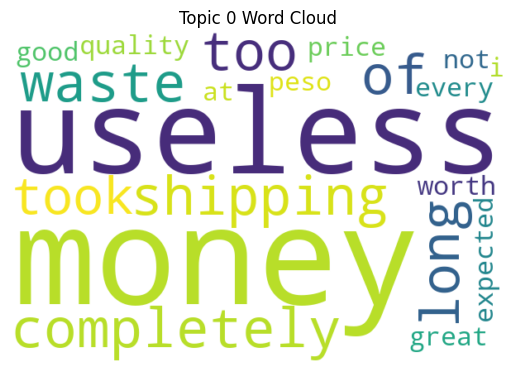

c:\Users\Jomar\VSCode\ML\School\schoolenv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


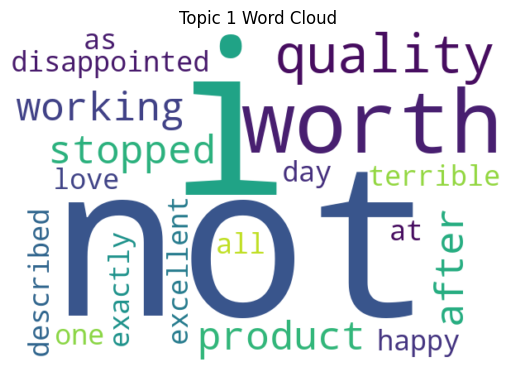

c:\Users\Jomar\VSCode\ML\School\schoolenv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


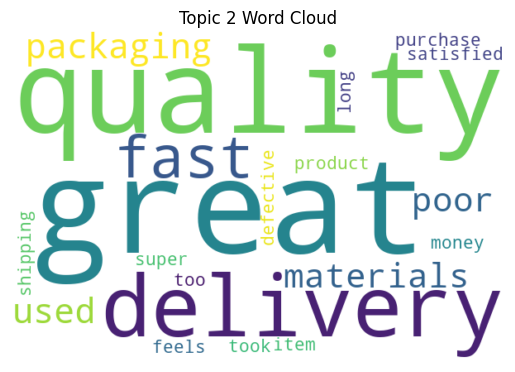

c:\Users\Jomar\VSCode\ML\School\schoolenv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


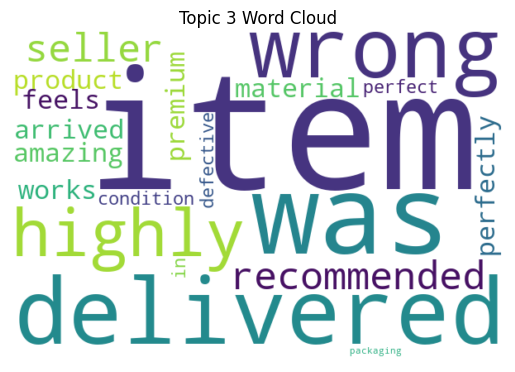

c:\Users\Jomar\VSCode\ML\School\schoolenv\Lib\site-packages\matplotlib\cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


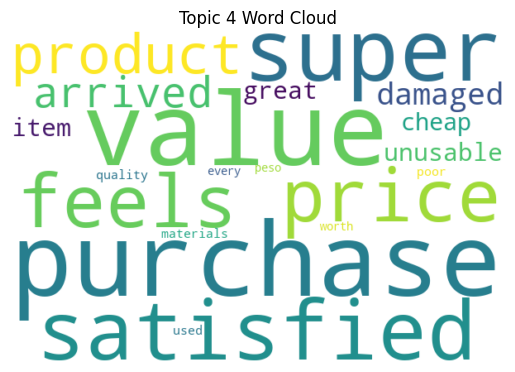

In [10]:
#word cloud for each topic

for t in range(5):
    plt.figure()
    topic_words = dict(lda_model.show_topic(t, topn = 20))
    wc = WordCloud(
        width = 600,
        height = 400,
        background_color = 'white'
    )
    wc.generate_from_frequencies(topic_words)
    plt.imshow(wc, interpolation = 'bilinear')
    plt.axis('off')
    plt.title(f"Topic {t} Word Cloud")
    plt.show()

In [11]:
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.216586  0.105340       1        1  34.795799
3      0.239277 -0.031899       2        1  24.162255
4      0.170253  0.053914       3        1  16.204076
0     -0.119261 -0.260756       4        1  13.015026
2     -0.073682  0.133401       5        1  11.822844, topic_info=        Term       Freq      Total Category  logprob  loglift
30      item  17.000000  17.000000  Default  30.0000  30.0000
5    quality  13.000000  13.000000  Default  29.0000  29.0000
20     great   9.000000   9.000000  Default  28.0000  28.0000
3      money   9.000000   9.000000  Default  27.0000  27.0000
18  delivery   5.000000   5.000000  Default  26.0000  26.0000
..       ...        ...        ...      ...      ...      ...
3      money   0.179881   9.679750   Topic5  -5.5842  -1.8504
23         i   0.179860   9.486184   Topic5  -5.5843  -1.8303
27   arrived   0.179843   9.186183   Topic5  -5.5844  -1.7982
7      worth   0.179827   9.485962   Topic5  -5.5845  -1.8304
4        not   0.179826   9.486185   Topic5  -5.5845  -1.8305

[214 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
57        1  0.772876    after
63        1  0.772825      all
8         2  0.800015  amazing
27        2  0.435437  arrived
27        3  0.435437  arrived
...     ...       ...      ...
66        1  0.772825     what
62        1  0.772876  working
10        2  0.800015    works
7         1  0.948770    worth
46        2  0.800064    wrong

[75 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 4, 5, 1, 3])